In [1]:
using Serialization
using Plots

res0 = deserialize("../examples/sia/runs/2d_solution_0res.jls");
res1 = deserialize("../examples/sia/runs/2d_solution_1res.jls");
res2 = deserialize("../examples/sia/runs/2d_solution_2res.jls");

# data  = x, y, h_list, t_list, dt_list, f_list
x0 = res0[1]
y0 = res0[2]
h0 = res0[3]
t0 = res0[4]

x1 = res1[1]
y1 = res1[2]
h1 = res1[3]
t1 = res1[4]

x2 = res2[1]
y2 = res2[2]
h2 = res2[3]
t2 = res2[4]

println(length(t0))
println(length(t1))
println(length(t2))


7
14
28


In [2]:
maximum(x0[:] - x1[1:2:end])

0.0

0.0
0.0
0.0


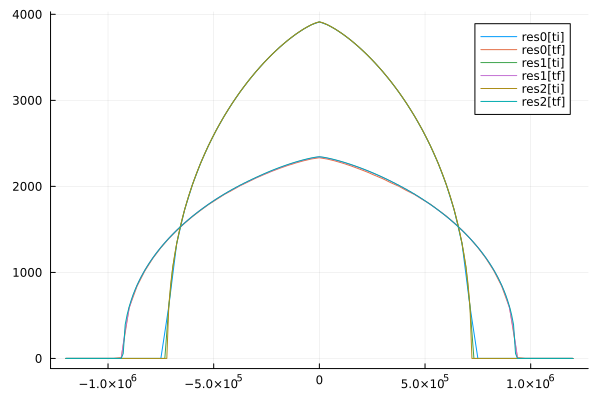

In [3]:
i0 = Int((length(x0)+1)/2)
println(x0[i0])
plot(x0, h0[1][:,i0], label="res0[ti]")
plot!(x0, h0[end][:,i0], label="res0[tf]")

i1 = Int((length(x1)+1)/2)
println(x1[i1])
plot!(x1, h1[1][:,i1], label="res1[ti]")
plot!(x1, h1[end][:,i1], label="res1[tf]")

i2 = Int((length(x2)+1)/2)
println(x2[i2])
plot!(x2, h2[1][:,i2], label="res2[ti]")
plot!(x2, h2[end][:,i2], label="res2[tf]")

In [4]:
# analytical solution
function Halfar(t,x,y)
    # copied from https://github.com/bueler/karthaus/blob/master/mfiles/halfar.m
    g = 9.81     # constants in SI units
    rho = 910.0
    secpera = 365*24*3600 # seconds per one year
    n = 3
    A = 1.0e-16/secpera
    Gamma  = 2.0 * A * (rho * g)^3 / 5.0 # see Bueler et al (2005)

    H0 = 3600.0
    R0 = 750.0e3
    alpha = 1/9#0.1111111111111111
    beta = 1/18#0.05555555555555555
    # for t0, see equation (9) in Bueler et al (2005); result is 422.45 a:
    t0 = (beta/Gamma) * (7/4)^3 * (R0^4/H0^7)

    t = t / t0
    Nx = length(x)
    Ny = length(y)
    inside = zeros(Nx, Ny)
    for i in 1:Nx
        for j in 1:Ny
            r = sqrt(x[i]^2 + y[j]^2)
            r = r / R0
            test = 1.0 - (r / t^beta)^((n+1) / n)
            if test > 0
                inside[i,j] = test
            end # if
        end # for i
    end # for j
    H = H0 .* inside.^(n / (2*n+1)) / t^alpha
    return H
end

Halfar (generic function with 1 method)

In [5]:
# for the run
res = 0 # double resol
Nx = 2^res*64
Ny = 2^res*64
L  = 1.7*1000e3
#L  = 100e3
x = range(-L, L, length=Nx)
y = range(-L, L, length=Ny)

secpera = 365*24*3600 # seconds per one year
t0 = 2*100*secpera

hi = Halfar(t0, x, y);

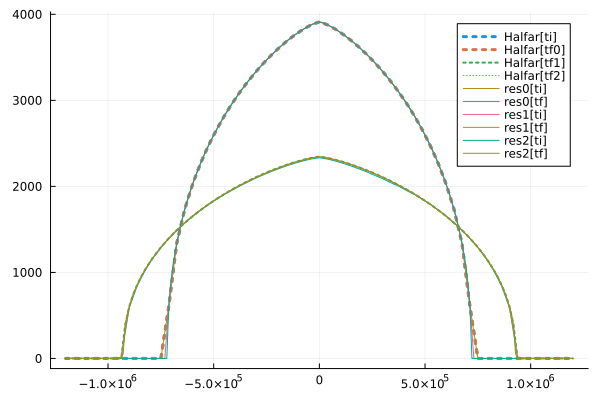

In [6]:
hi = Halfar(t0[1], x0, y0)

tf0 = t0[end]
hf0 = Halfar(tf0, x0, y0)

tf1 = t1[end]
hf1 = Halfar(tf1, x1, y1)

tf2 = t2[end]
hf2 = Halfar(tf2, x2, y2)

plot(x0, hi[:,i0], label="Halfar[ti]", linewidth = 3, linestyle = :dot)
plot!(x0, hf0[:,i0], label="Halfar[tf0]", linewidth = 3, linestyle = :dot)
plot!(x1, hf1[:,i1], label="Halfar[tf1]", linewidth = 2, linestyle = :dot)
plot!(x2, hf2[:,i2], label="Halfar[tf2]", linewidth = 1, linestyle = :dot)

plot!(x0, h0[1][:,i0], label="res0[ti]")
plot!(x0, h0[end][:,i0], label="res0[tf]")

plot!(x1, h1[1][:,i1], label="res1[ti]")
plot!(x1, h1[end][:,i1], label="res1[tf]")

plot!(x2, h2[1][:,i2], label="res2[ti]")
plot!(x2, h2[end][:,i2], label="res2[tf]")

In [7]:
dx0 = x0[end] - x0[end-1]
dx1 = x1[end] - x1[end-1]
dx2 = x2[end] - x2[end-1]

R = (dx0-dx1)/(dx1-dx2)

2.0

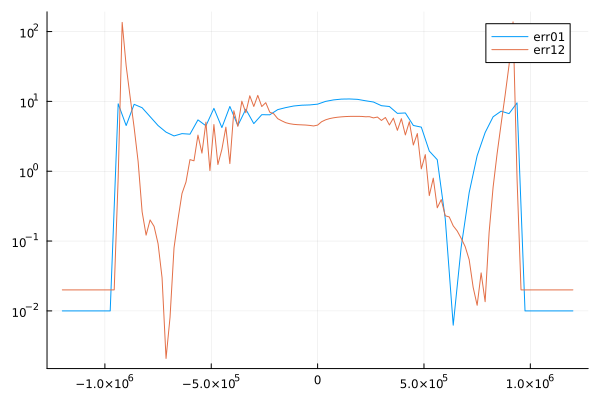

In [8]:
maximum(x0 - x1[1:2:end])
maximum(x1 - x2[1:2:end])

err01 = h0[end] .- h1[end][1:2:end, 1:2:end];
err12 = h1[end] .- h2[end][1:2:end, 1:2:end];

plot(x0, abs.(err01 .+ 1e-2)[i0,:], label="err01", yscale = :log10)
plot!(x1, 2*abs.(err12 .+ 1e-2)[i1,:], label="err12", yscale = :log10)

In [9]:
err0 = h0[end] - hf0;
err1 = h1[end] - hf1;
err2 = h2[end] - hf2;

av_err0 = sum(abs.(err0))/(length(x0)*length(y0))
av_err1 = sum(abs.(err1))/(length(x1)*length(y1))
av_err2 = sum(abs.(err2))/(length(x2)*length(y2))

println(av_err0)
println(av_err1)
println(av_err2)

384.717516566767
2.3895472372298503
0.8938047126002537


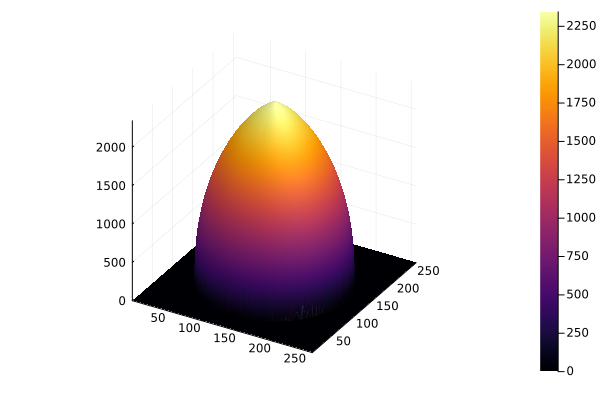

In [18]:
surface(h2[end])